In [1]:
import os
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import mycolorpy.colorlist as mcp
from collections import Counter
from matplotlib.patches import Rectangle
import utils
import matplotlib as mpl
import geopandas as gpd
import contextily as ctx
from shapely.geometry import LineString
from shapely.geometry import Point
from matplotlib.ticker import FuncFormatter
import itertools
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

In [2]:
def load_aimsun(plan_name, rep=None):
    df = pd.read_parquet(f"../data/processed/{plan_name}_aimsun.parquet")
    if rep == None:
        return df
    else:
        return df[df["rep"] == rep].copy()

def load_network(plan_name, rep=None):
    df = pd.read_parquet(f"../data/processed/{plan_name}_network.parquet")
    if rep == None:
        return df
    else:
        return df[df["rep"] == rep].copy()

def load_critical(plan_name, rep=-1):
    df_summary = pd.read_parquet(f"../data/processed/{plan_name}_critical_summary.parquet")
    df_vector = pd.read_parquet(f"../data/processed/{plan_name}_critical_vector.parquet")

    critical_time = df_summary.loc[df_summary["rep"] == rep, "critical_time"].iloc[0]

    critical_loc = df_vector.loc[
        (df_vector["rep"] == rep) & (df_vector["type"] == "critical_loc"),
        "value"
    ].to_numpy()

    intersection = df_vector.loc[
        (df_vector["rep"] == rep) & (df_vector["type"] == "intersection"),
        "value"
    ].to_numpy()

    return critical_time, critical_loc, intersection

In [3]:
def plot_basemap_with_intersections(
    intersections,
    figsize=(3, 5.2),
    save_path=None
):
    # ===== shapefile base =====
    roads = gpd.read_file("../data/external/aimsun_topo/section_edit.shp")
    if roads.crs is None:
        raise ValueError("Shapefile has no CRS.")
    roads_3857 = roads.to_crs(epsg=3857)

    # ===== graph =====
    load = utils.LoadData()
    G_primal, G_dual = load.load_map_data(
        '../data/external/aimsun_topo/section_edit.shp',
        '../data/external/aimsun_topo/nodes.shp'
    )

    geoms = []
    for n in intersections:
        loc = G_primal.nodes[n]["loc"]
        geoms.append(Point(loc.x, loc.y))

    gdf_intersections = gpd.GeoDataFrame(
        geometry=geoms,
        crs=roads.crs
    ).to_crs(epsg=3857)

    # ===== extent =====
    xmin, ymin, xmax, ymax = roads_3857.total_bounds
    dx = xmax - xmin
    dy = ymax - ymin
    xmin -= 0.02 * dx
    xmax += 0.02 * dx
    ymin -= 0.02 * dy
    ymax += 0.02 * dy

    # ===== plot =====
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.PositronNoLabels,
        attribution=False
    )

    roads_3857.plot(
        ax=ax,
        color="#A8A8A8",
        linewidth=1,
        alpha=0.5,
        zorder=2
    )

    gdf_intersections.plot(
        ax=ax,
        facecolor=plt.cm.Set2.colors[1],
        edgecolor="black",
        markersize=25,
        linewidth=0.5,
        zorder=5
    )

    # ===== add black frame =====
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    rect = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        edgecolor="black",
        linewidth=1.2,
        zorder=10,
        clip_on=False
    )

    ax.add_patch(rect)

    ax.set_aspect("auto")
    ax.set_axis_off()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()

In [4]:
def _line_endpoints(geom):
    """
    Return start/end coordinates of a LineString or MultiLineString.
    """
    if geom.geom_type == "LineString":
        coords = list(geom.coords)
        return np.array(coords[0]), np.array(coords[-1])
    elif geom.geom_type == "MultiLineString":
        first = list(geom.geoms[0].coords)
        last = list(geom.geoms[-1].coords)
        return np.array(first[0]), np.array(last[-1])
    else:
        return None, None


def _endpoint_match_score(a1, a2, b1, b2):
    """
    Distance between two undirected segments:
    compare both orientations and take the smaller one.
    """
    s1 = np.linalg.norm(a1 - b1) + np.linalg.norm(a2 - b2)
    s2 = np.linalg.norm(a1 - b2) + np.linalg.norm(a2 - b1)
    return min(s1, s2)


def _match_edges_to_shapefile(G_primal, selected_edges, roads_gdf):
    """
    Match selected G_primal edges to shapefile geometries using endpoints.
    Returns a GeoDataFrame with true curved geometry from shapefile.
    """
    # precompute shapefile endpoints
    shp = roads_gdf.copy()
    shp["_p1"], shp["_p2"] = zip(*shp.geometry.apply(_line_endpoints))

    rows = []

    for u, v, k, e in selected_edges:
        x1, y1 = G_primal.nodes[u]["loc"].x, G_primal.nodes[u]["loc"].y
        x2, y2 = G_primal.nodes[v]["loc"].x, G_primal.nodes[v]["loc"].y
        p1 = np.array([x1, y1])
        p2 = np.array([x2, y2])

        # score every shapefile feature by endpoint similarity
        valid = shp[shp["_p1"].notna()].copy()
        valid["_score"] = valid.apply(
            lambda r: _endpoint_match_score(p1, p2, r["_p1"], r["_p2"]),
            axis=1
        )

        # take best match
        best = valid.sort_values("_score").iloc[0]

        rows.append({
            "u": u,
            "v": v,
            "k": k,
            "name": e.get("name"),
            "cluster": e.get("cluster"),
            "geometry": best.geometry
        })

    gdf = gpd.GeoDataFrame(rows, geometry="geometry", crs=roads_gdf.crs)
    return gdf


def plot_two_largest_components_basemap(
    G_selected,
    G_primal,
    candidate=None,
    edges_to_move=None,
    selected_edges=None,
    figsize=(3, 5.2),
    zoom_buffer=250,
    save_path=None,
):
    # ===== shapefile base =====
    roads = gpd.read_file("../data/external/aimsun_topo/section_edit.shp")
    if roads.crs is None:
        raise ValueError("Shapefile has no CRS.")
    roads_3857 = roads.to_crs(epsg=3857)

    # ===== components =====
    G_und = G_selected.to_undirected() if G_selected.is_directed() else G_selected
    comps = sorted(nx.connected_components(G_und), key=len, reverse=True)

    if not comps:
        raise ValueError("No components found in the graph.")

    largest_nodes = comps[0]
    second_nodes = comps[1] if len(comps) > 1 else set()

    H1 = G_selected.subgraph(largest_nodes).copy()
    H2 = G_selected.subgraph(second_nodes).copy() if second_nodes else None

    # ===== collect selected edge names =====
    largest_edge_names = {
        e.get("name")
        for _, _, _, e in H1.edges(data=True, keys=True)
        if e.get("name") is not None
    }

    second_edge_names = set()
    if H2 is not None:
        second_edge_names = {
            e.get("name")
            for _, _, _, e in H2.edges(data=True, keys=True)
            if e.get("name") is not None
        }

    # ===== match selected edges back to G_primal =====
    selected_edges_largest = [
        (u, v, k, e)
        for u, v, k, e in G_primal.edges(data=True, keys=True)
        if e.get("name") in largest_edge_names
    ]

    selected_edges_second = [
        (u, v, k, e)
        for u, v, k, e in G_primal.edges(data=True, keys=True)
        if e.get("name") in second_edge_names
    ]

    # ===== use true shapefile geometries =====
    gdf_largest = None
    gdf_second = None

    if len(selected_edges_largest) > 0:
        gdf_largest = _match_edges_to_shapefile(
            G_primal,
            selected_edges_largest,
            roads
        ).to_crs(epsg=3857)

    if len(selected_edges_second) > 0:
        gdf_second = _match_edges_to_shapefile(
            G_primal,
            selected_edges_second,
            roads
        ).to_crs(epsg=3857)

    # ===== critical intersections: endpoints of candidate section =====

    critical_edges = [
        (u, v, k, e)
        for u, v, k, e in G_primal.edges(data=True, keys=True)
        if e.get("name") == candidate
    ]

    gdf_candidate = _match_edges_to_shapefile(
    G_primal,
    critical_edges,
    roads
    ).to_crs(epsg=3857)

    gdf_candidate_intersections = None

    if len(critical_edges) > 0:
        point_rows = []

        for u, v, k, e in critical_edges:
            for n in [u, v]:
                loc = G_primal.nodes[n]["loc"]
                point_rows.append({
                    "node": n,
                    "candidate": candidate,
                    "geometry": Point(loc.x, loc.y)
                })

        gdf_candidate_intersections = gpd.GeoDataFrame(
            point_rows,
            geometry="geometry",
            crs=roads.crs
        ).drop_duplicates(subset=["node"])

        gdf_candidate_intersections_3857 = gdf_candidate_intersections.to_crs(epsg=3857)
    
    # ===== restored removed edges =====
    restored_edges_largest = [
        (u, v, k, e)
        for u, v, k, e in G_primal.edges(data=True, keys=True)
        if (
            e.get("name") in edges_to_move
            and e.get("name") != candidate
            and (u in largest_nodes or v in largest_nodes)
        )
    ]

    restored_edges_second = [
        (u, v, k, e)
        for u, v, k, e in G_primal.edges(data=True, keys=True)
        if (
            e.get("name") in edges_to_move
            and e.get("name") != candidate
            and (u in second_nodes or v in second_nodes)
        )
    ]

    print("restored largest:", len(restored_edges_largest))
    print("restored second:", len(restored_edges_second))

    gdf_restored_largest = None
    gdf_restored_second = None

    if len(restored_edges_largest) > 0:
        gdf_restored_largest = _match_edges_to_shapefile(
            G_primal, restored_edges_largest, roads
        ).to_crs(epsg=3857)

    if len(restored_edges_second) > 0:
        gdf_restored_second = _match_edges_to_shapefile(
            G_primal, restored_edges_second, roads
        ).to_crs(epsg=3857)

    # ===== extent =====
    xmin, ymin, xmax, ymax = roads_3857.total_bounds
    dx = xmax - xmin
    dy = ymax - ymin
    xmin -= 0.02 * dx
    xmax += 0.02 * dx
    ymin -= 0.02 * dy
    ymax += 0.02 * dy

    # ===== plot =====
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.PositronNoLabels,
        attribution=False
    )

    # base sections
    roads_3857.plot(
        ax=ax,
        color="#A8A8A8",
        linewidth=1,
        alpha=0.5,
        zorder=2
    )

    # largest component
    if gdf_largest is not None and len(gdf_largest) > 0:
        gdf_largest.plot(
            ax=ax,
            color=plt.cm.Set2.colors[0],
            linewidth=1.8,
            alpha=0.95,
            zorder=4,
            label=f"Largest"
        )

    # second-largest component
    if gdf_second is not None and len(gdf_second) > 0:
        gdf_second.plot(
            ax=ax,
            color=plt.cm.Set2.colors[1],
            linewidth=1.8,
            alpha=0.95,
            zorder=5,
            label=f"Second"
        )

    if gdf_candidate is not None and len(gdf_candidate) > 0:
        gdf_candidate.plot(
            ax=ax,
            color="black",
            linewidth=3.0,
            alpha=1.0,
            zorder=8
        )

    # restored edges connected to largest component
    if gdf_restored_largest is not None and len(gdf_restored_largest) > 0:
        gdf_restored_largest.plot(
            ax=ax,
            color=plt.cm.Set2.colors[0],
            linewidth=1.8,
            alpha=0.95,
            zorder=5
        )

    # restored edges connected to second component
    if gdf_restored_second is not None and len(gdf_restored_second) > 0:
        gdf_restored_second.plot(
            ax=ax,
            color=plt.cm.Set2.colors[1],
            linewidth=1.9,
            alpha=0.95,
            zorder=5
        )

    # critical candidate section
    if gdf_candidate_intersections is not None and len(gdf_candidate_intersections) > 0:
        gdf_candidate_intersections_3857.plot(
            ax=ax,
            facecolor="orange",
            edgecolor="black",
            markersize=35,
            linewidth=0.6,
            zorder=8,
            label="Critical intersection"
        )

    # ===== zoom-in inset around critical intersections =====
    if gdf_candidate_intersections is not None and len(gdf_candidate_intersections) > 0:

        # zoom extent based on critical intersections
        zxmin, zymin, zxmax, zymax = gdf_candidate_intersections_3857.total_bounds

        cx = (zxmin + zxmax) / 2
        cy = (zymin + zymax) / 2

        zoom_size = 1000  # meter，调这个控制覆盖范围大小

        zxmin = cx - zoom_size / 2
        zxmax = cx + zoom_size / 2
        zymin = cy - zoom_size / 2
        zymax = cy + zoom_size / 2

        # ===== draw zoom rectangle on main map =====
        zoom_rect = Rectangle(
            (zxmin, zymin),
            zoom_size,
            zoom_size,
            fill=False,
            edgecolor="black",
            linewidth=1.2,
            linestyle="-",
            zorder=11
        )
        ax.add_patch(zoom_rect)

        # ===== inset axes at lower left =====
        axins = inset_axes(
            ax,
            width=1,     
            height=1,
            loc="lower left",
            borderpad=0.6
        )

        axins.set_xlim(zxmin, zxmax)
        axins.set_ylim(zymin, zymax)
        axins.set_aspect("equal", adjustable="box")

        ctx.add_basemap(
            axins,
            source=ctx.providers.CartoDB.PositronNoLabels,
            attribution=False
        )

        # base roads
        roads_3857.plot(
            ax=axins,
            color="#A8A8A8",
            linewidth=0.8,
            alpha=0.5,
            zorder=2
        )

        # largest component
        if gdf_largest is not None and len(gdf_largest) > 0:
            gdf_largest.plot(
                ax=axins,
                color=plt.cm.Set2.colors[0],
                linewidth=1.6,
                alpha=0.95,
                zorder=4
            )

        # restored largest edges
        if gdf_restored_largest is not None and len(gdf_restored_largest) > 0:
            gdf_restored_largest.plot(
                ax=axins,
                color=plt.cm.Set2.colors[0],
                linewidth=1.6,
                alpha=0.95,
                zorder=5
            )

        # second component
        if gdf_second is not None and len(gdf_second) > 0:
            gdf_second.plot(
                ax=axins,
                color=plt.cm.Set2.colors[1],
                linewidth=1.6,
                alpha=0.95,
                zorder=4
            )

        # restored second edges
        if gdf_restored_second is not None and len(gdf_restored_second) > 0:
            gdf_restored_second.plot(
                ax=axins,
                color=plt.cm.Set2.colors[1],
                linewidth=1.6,
                alpha=0.95,
                zorder=5
            )

        # critical section
        if gdf_candidate is not None and len(gdf_candidate) > 0:
            gdf_candidate.plot(
                ax=axins,
                color="black",
                linewidth=3.0,
                alpha=1.0,
                zorder=8
            )

        # critical intersections
        gdf_candidate_intersections_3857.plot(
            ax=axins,
            facecolor="orange",
            edgecolor="black",
            markersize=40,
            linewidth=0.7,
            zorder=9
        )

        xmin_i, xmax_i = axins.get_xlim()
        ymin_i, ymax_i = axins.get_ylim()

        rect_ins = Rectangle(
            (xmin_i, ymin_i),
            xmax_i - xmin_i,
            ymax_i - ymin_i,
            fill=False,
            edgecolor="black",
            linewidth=1.5,
            zorder=20,
            clip_on=False
        )

        axins.add_patch(rect_ins)
        # axins.set_aspect("auto")
        axins.set_axis_off()
    

    # ===== black frame =====
    xmin_, xmax_ = ax.get_xlim()
    ymin_, ymax_ = ax.get_ylim()

    rect = Rectangle(
        (xmin_, ymin_),
        xmax_ - xmin_,
        ymax_ - ymin_,
        fill=False,
        edgecolor="black",
        linewidth=1.2,
        zorder=10,
        clip_on=False
    )
    ax.add_patch(rect)

    ax.set_aspect("auto")
    ax.set_axis_off()

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()

    return H1, H2, gdf_largest, gdf_second

In [5]:
load = utils.LoadData()
G_primal, G_dual = load.load_map_data(
    '../data/external/aimsun_topo/section_edit.shp',
    '../data/external/aimsun_topo/nodes.shp'
)
interval = 5

total = load_aimsun("Fix", rep=-1)
critical_time, critical_loc_mean, intersection_mean = load_critical("Fix", rep=-1)
critical_time = 57

# Process each time step
times, sections, sizes = [], [], []

for ent in np.sort(total['ent'].unique()):
    total_ent = total[total.ent == ent]
    G = G_dual.copy()

    # Update graph nodes with traffic data
    for _, row in total_ent.iterrows():
        start = int(row['oid'])
        try:
            G.nodes[start].update({
                "congest": row['if_congest'],
                "flow": row['flow'],
                "density": row['density'],
                "speed": row['speed']
            })
        except KeyError:
            continue
    
    cg_subgraph, cg_sizes = utils.process_subgraph(G, condition=1)
    for i in range(len(cg_subgraph)):
        sections.append(cg_subgraph[i])
        sizes.append(cg_sizes[i])
        times.append(ent)

congest_loc = pd.DataFrame({'section': sections, 'sizes': sizes, 'time': times}).sort_values(by='time')

# Get the nodes for ent1
list2d = list(congest_loc[congest_loc['time'] == critical_time].sort_values(by=['sizes'], ascending=False).section.values)
edge1 = list(itertools.chain(*list2d))

# Get the nodes for ent2
edge2 = congest_loc[congest_loc['time'] == critical_time+interval].sort_values(by=['sizes'], ascending=False).section.values[0]

candidate_records = []
candidates = list(set(edge2).difference(set(edge1)))

for candidate in candidates:
    G = G_primal.copy()

    selected_nodes = [
        [u, v] for u, v, k, e in G.edges(data=True, keys=True)
        if e['name'] in set([candidate])
    ]
    
    selected_nodes = set([x for sublist in selected_nodes for x in sublist])
    
    edges_to_move = [
        e['name'] for u, v, k, e in G.edges(data=True, keys=True)
        if u in selected_nodes or v in selected_nodes
    ]
    
    selected_edges = [
        (u, v, k) for u, v, k, e in G.edges(data=True, keys=True)
        if e['name'] in list(set(edge2).difference(set(edges_to_move)))
    ]
    
    G_selected = G.edge_subgraph(selected_edges)
    
    largest_component_size = len(sorted(nx.connected_components(G_selected), key=len, reverse=True)[0])
    second_component_size = len(sorted(nx.connected_components(G_selected), key=len, reverse=True)[1]) if len(sorted(nx.connected_components(G_selected), key=len, reverse=True)) > 1 else 0
    lg_ratio = largest_component_size / len(edge2)

    candidate_records.append({
        "candidate": candidate,
        "largest_component_size": largest_component_size,
        "second_component_size": second_component_size,
        "lg_ratio": lg_ratio,
        "selected_edges": selected_edges,
        "edges_to_move": edges_to_move
    })

df_bottleneck = pd.DataFrame(candidate_records)

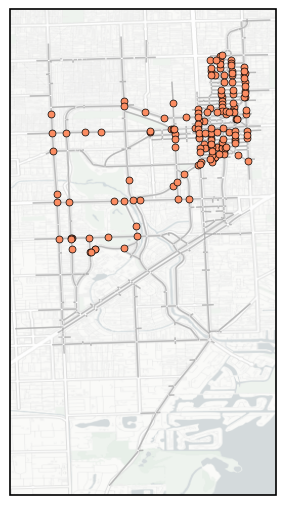

restored largest: 3
restored second: 2


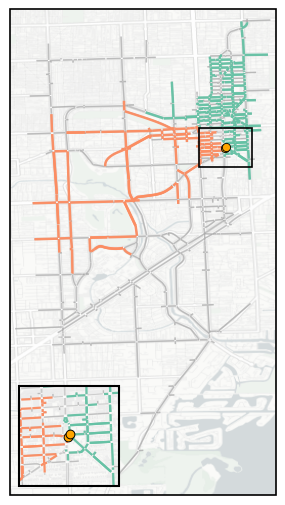

restored largest: 2
restored second: 2


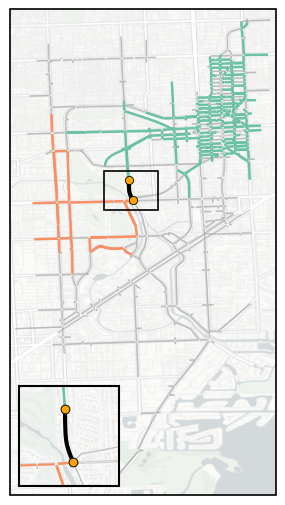

restored largest: 6
restored second: 4


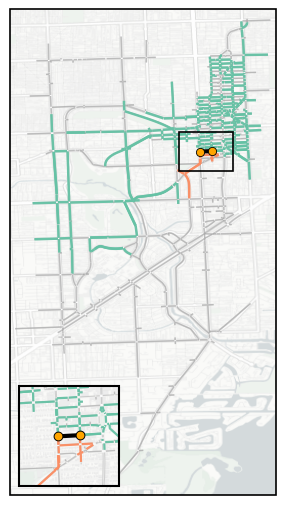

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


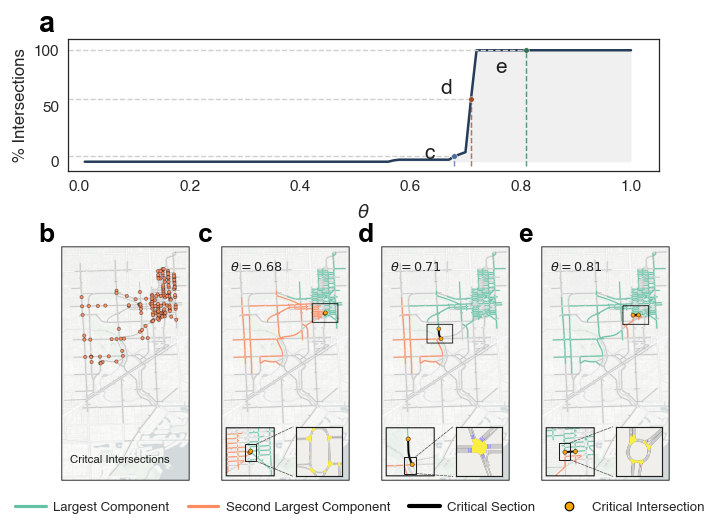

In [7]:
# Fig. 2 composite panel
from pathlib import Path
from matplotlib.patches import ConnectionPatch
import matplotlib.patheffects as pe


# This cell keeps the original Fig. 2 analysis above intact and assembles a manuscript-style panel.

FIG2_PALETTE = {
    "teal": "#2CA58D",
    "orange": "#F4743B",
    "blue": "#496C9E",
    "brown": "#9A4D24",
    "green": "#2F7355",
    "navy": "#263D5A",
    "gray": "#7A7A7A",
    "light_gray": "#CFCFCF",
    "black": "#1F1F1F",
}


def set_fig2_panel_style():
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "mathtext.fontset": "dejavusans",
        "font.size": 11.5,
        "axes.labelsize": 12.0,
        "xtick.labelsize": 11.0,
        "ytick.labelsize": 11.0,
        "axes.linewidth": 0.9,
        "xtick.major.width": 0.9,
        "ytick.major.width": 0.9,
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    })


def get_fig2_selected_cases(df_bottleneck):
    df_plot = df_bottleneck.copy()
    df_plot["group"] = pd.cut(
        df_plot["lg_ratio"],
        bins=[-float("inf"), 0.6, 0.7, float("inf")],
        labels=["<0.6", "0.6-0.7", ">0.7"],
        right=False,
    )

    selected = {}
    for group in ["<0.6", "0.6-0.7", ">0.7"]:
        tmp = df_plot[df_plot["group"] == group]
        selected[group] = None if len(tmp) == 0 else tmp.sort_values("lg_ratio").iloc[0]
    return selected


def render_fig2_map_parts(
    output_dir="../figure/fig2_panel_parts",
    plan_name="Fix",
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    total = load_aimsun(plan_name, rep=-1)
    _, _, intersection_mean = load_critical(plan_name, rep=-1)

    map_paths = []
    path_b = output_dir / "panel_b.png"
    plot_basemap_with_intersections(
        intersection_mean,
        figsize=(3, 5.2),
        save_path=str(path_b),
    )
    map_paths.append(path_b)

    selected_cases = get_fig2_selected_cases(df_bottleneck)
    for label, group in zip(["c", "d", "e"], ["<0.6", "0.6-0.7", ">0.7"]):
        row = selected_cases[group]
        if row is None:
            raise ValueError(f"No selected bottleneck case for group {group}")

        G_selected = G_primal.edge_subgraph(row["selected_edges"]).copy()
        out_path = output_dir / f"panel_{label}.png"
        plot_two_largest_components_basemap(
            G_selected,
            G_primal,
            row["candidate"],
            row["edges_to_move"],
            row["selected_edges"],
            figsize=(3, 5.2),
            save_path=str(out_path),
        )
        map_paths.append(out_path)

    return map_paths


def plot_fig2_threshold_panel(ax, plan_name="Fix", thresholds=(0.68, 0.71, 0.81)):
    df_res = pd.read_parquet(f"../data/processed/{plan_name}_critical_scaling.parquet")
    x_vals = df_res["threshold"].to_numpy()
    y_norm = df_res["num_intersections"].to_numpy() / df_res["num_intersections"].max()

    ax.fill_between(
        x_vals,
        0,
        y_norm,
        color=FIG2_PALETTE["light_gray"],
        alpha=0.30,
        linewidth=0,
        zorder=0,
    )
    ax.plot(x_vals, y_norm, color=FIG2_PALETTE["navy"], linewidth=1.8, zorder=2)
    ax.set_xlim(-0.02, 1.05)
    ax.set_ylim(-0.08, 1.10)
    ax.set_xlabel("")
    ax.text(
        0.50,
        -0.32,
        r"$\theta$",
        transform=ax.transAxes,
        fontsize=13.2,
        ha="center",
        va="center",
    )
    ax.set_ylabel("% Intersections")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y * 100:.0f}"))

    label_colors = {
        "c": FIG2_PALETTE["blue"],
        "d": FIG2_PALETTE["brown"],
        "e": FIG2_PALETTE["green"],
    }
    for th, label, yoff in zip(thresholds, ["c", "d", "e"], [0.03, 0.09, -0.15]):
        y = float(np.interp(th, x_vals, y_norm))
        color = label_colors[label]
        ax.vlines(th, -0.04, y, color=color, linestyle="--", linewidth=1.05, alpha=0.75)
        ax.hlines(y, -0.02, th, color=FIG2_PALETTE["light_gray"], linestyle="--", linewidth=1.0)
        ax.plot(th, y, marker="o", markersize=4.0, color=color, markeredgecolor="white", markeredgewidth=0.35)
        ax.text(
            th - 0.035,
            min(max(y + yoff, 0.05), 0.97),
            label,
            fontsize=15,
            fontweight="normal",
            color=FIG2_PALETTE["black"],
            ha="right",
            va="center",
        )

    for spine in ax.spines.values():
        spine.set_linewidth(0.9)


def generate_fig2_composite_panel(
    save_pdf="../figure/fig2_panel.pdf",
    save_png="../figure/fig2_panel.png",
    plan_name="Fix",
):
    set_fig2_panel_style()
    os.makedirs(os.path.dirname(save_pdf), exist_ok=True)

    map_paths = render_fig2_map_parts(
        output_dir="../figure/fig2_panel_parts",
        plan_name=plan_name,
    )

    fig = plt.figure(figsize=(7.2, 5.22), facecolor="white")

    ax_a = fig.add_axes([0.12, 0.692, 0.82, 0.252])
    plot_fig2_threshold_panel(ax_a, plan_name=plan_name)
    ax_a.text(
        -0.05,
        1.01,
        "a",
        transform=ax_a.transAxes,
        fontsize=21.0,
        fontfamily="Arial",
        fontweight="heavy",
        color="black",
        ha="left",
        va="bottom",
        clip_on=False,
    )

    left = 0.105
    gap = 0.032
    width = 0.19
    y0 = 0.072
    height = 0.50
    intersection_insets = {
        "c": "../figure/intersection1.png",
        "d": "../figure/intersection2.png",
        "e": "../figure/intersection3.png",
    }

    panel_label_colors = {
        "b": FIG2_PALETTE["black"],
        "c": FIG2_PALETTE["black"],
        "d": FIG2_PALETTE["black"],
        "e": FIG2_PALETTE["black"],
    }
    badge_specs = {
        "b": ("Critcal Intersections", FIG2_PALETTE["black"], 0.095, 0.085, "left", "bottom"),
        "c": (r"$\theta = 0.68$", FIG2_PALETTE["black"], 0.095, 0.925, "left", "top"),
        "d": (r"$\theta = 0.71$", FIG2_PALETTE["black"], 0.095, 0.925, "left", "top"),
        "e": (r"$\theta =  0.81$", FIG2_PALETTE["black"], 0.095, 0.925, "left", "top"),
    }

    for i, (label, path) in enumerate(zip(["b", "c", "d", "e"], map_paths)):
        ax = fig.add_axes([left + i * (width + gap), y0, width, height])
        img = plt.imread(path)
        ax.imshow(img)
        ax.set_axis_off()
        ax.text(
            -0.14,
            0.985,
            label,
            transform=ax.transAxes,
            fontsize=19.0,
            fontfamily="Arial",
            fontweight="heavy",
            color="black",
            ha="left",
            va="bottom",
            clip_on=False,
        )
        badge_text, badge_color, badge_x, badge_y, badge_ha, badge_va = badge_specs[label]
        badge_fontsize = 8.2 if label == "b" else 9.2
        badge_fontweight = "normal"
        badge_path_effects = []
        ax.text(
            badge_x,
            badge_y,
            badge_text,
            transform=ax.transAxes,
            fontsize=badge_fontsize,
            fontweight=badge_fontweight,
            color=badge_color,
            ha=badge_ha,
            va=badge_va,
            path_effects=badge_path_effects,
            zorder=40,
            clip_on=False,
        )

        if label in intersection_insets:
            # Match the existing lower-left network inset size and show which part is enlarged.
            left_inset_box = [0.035, 0.035, 0.38, 0.205]
            right_inset_box = [0.555, 0.035, 0.38, 0.205]
            zoom_w = 0.085
            zoom_h = 0.070
            zoom_boxes = {
                "c": [0.200, 0.098, zoom_w, zoom_h],
                "d": [0.198, 0.047, zoom_w, zoom_h],
                "e": [0.158, 0.104, zoom_w, zoom_h],
            }

            inset = ax.inset_axes(right_inset_box)
            inset_img = plt.imread(intersection_insets[label])
            inset.imshow(inset_img)
            inset.set_xticks([])
            inset.set_yticks([])
            for spine in inset.spines.values():
                spine.set_visible(True)
                spine.set_color(FIG2_PALETTE["black"])
                spine.set_linewidth(0.85)

            zx, zy, zw, zh = zoom_boxes[label]
            zoom_rect = Rectangle(
                (zx, zy),
                zw,
                zh,
                transform=ax.transAxes,
                fill=False,
                edgecolor=FIG2_PALETTE["black"],
                linewidth=0.75,
                zorder=20,
                clip_on=False,
            )
            ax.add_patch(zoom_rect)

            for y_src, y_dst in [(zy + zh, right_inset_box[1] + right_inset_box[3]), (zy, right_inset_box[1])]:
                con = ConnectionPatch(
                    xyA=(zx + zw, y_src),
                    coordsA=ax.transAxes,
                    xyB=(right_inset_box[0], y_dst),
                    coordsB=ax.transAxes,
                    axesA=ax,
                    axesB=ax,
                    color=FIG2_PALETTE["black"],
                    linewidth=0.55,
                    linestyle="--",
                    alpha=0.72,
                    zorder=19,
                    clip_on=False,
                )
                ax.add_artist(con)

    legend_handles = [
        Line2D([0], [0], color=plt.cm.Set2.colors[0], lw=2.3, label="Largest Component"),
        Line2D([0], [0], color=plt.cm.Set2.colors[1], lw=2.3, label="Second Largest Component"),
        Line2D([0], [0], color="black", lw=3.0, solid_capstyle="round", label="Critical Section"),
        Line2D([0], [0], marker="o", linestyle="None", markerfacecolor="orange",
               markeredgecolor="black", markeredgewidth=0.8, markersize=6.2,
               label="Critical Intersection"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.525, 0.012),
        ncol=4,
        frameon=False,
        fontsize=9.5,
        handlelength=2.3,
        handletextpad=0.55,
        columnspacing=1.45,
    )

    fig.savefig(save_pdf, dpi=600, bbox_inches="tight", facecolor="white")
    # fig.savefig(save_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)


generate_fig2_composite_panel()